In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.statistics import StatisticalAnalyzer

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_processed_data()
analyzer = StatisticalAnalyzer(df)

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully
Rows: 649
Columns: 33


In [2]:
confidence_columns = [
    "age",
    "absences",
    "G1",
    "G2",
    "G3"
]

comparison_rows = []

for column in confidence_columns:
    traditional = analyzer.confidence_interval(
        column,
        confidence=0.95
    )

    bootstrap = analyzer.bootstrap_ci(
        column,
        n_bootstrap=10000,
        confidence=0.95,
        random_seed=42
    )

    comparison_rows.append({
        "column": column,
        "mean": traditional["mean"],
        "ci_lower": traditional["lower_bound"],
        "ci_upper": traditional["upper_bound"],
        "bootstrap_lower": bootstrap["lower_bound"],
        "bootstrap_upper": bootstrap["upper_bound"],
        "ci_width": (
            traditional["upper_bound"]
            - traditional["lower_bound"]
        ),
        "bootstrap_width": (
            bootstrap["upper_bound"]
            - bootstrap["lower_bound"]
        )
    })

comparison_df = pd.DataFrame(comparison_rows)

print(comparison_df.round(3))

     column    mean  ci_lower  ci_upper  bootstrap_lower  bootstrap_upper  \
0       age  16.744    16.651    16.838           16.652           16.840   
1  absences   3.659     3.302     4.017            3.307            4.032   
2        G1  11.399    11.188    11.610           11.186           11.609   
3        G2  11.570    11.346    11.794           11.339           11.797   
4        G3  11.906    11.657    12.155           11.652           12.151   

   ci_width  bootstrap_width  
0     0.187            0.188  
1     0.714            0.726  
2     0.422            0.422  
3     0.448            0.458  
4     0.497            0.499  


In [3]:
confidence_output_file = (
    REPORTS_DIR
    / "ci_comparison.csv"
)

comparison_df.to_csv(
    confidence_output_file,
    index=False
)

print("Saved to:", confidence_output_file)

Saved to: /Users/hsumonsan/Statistics-superstars/reports/ci_comparison.csv


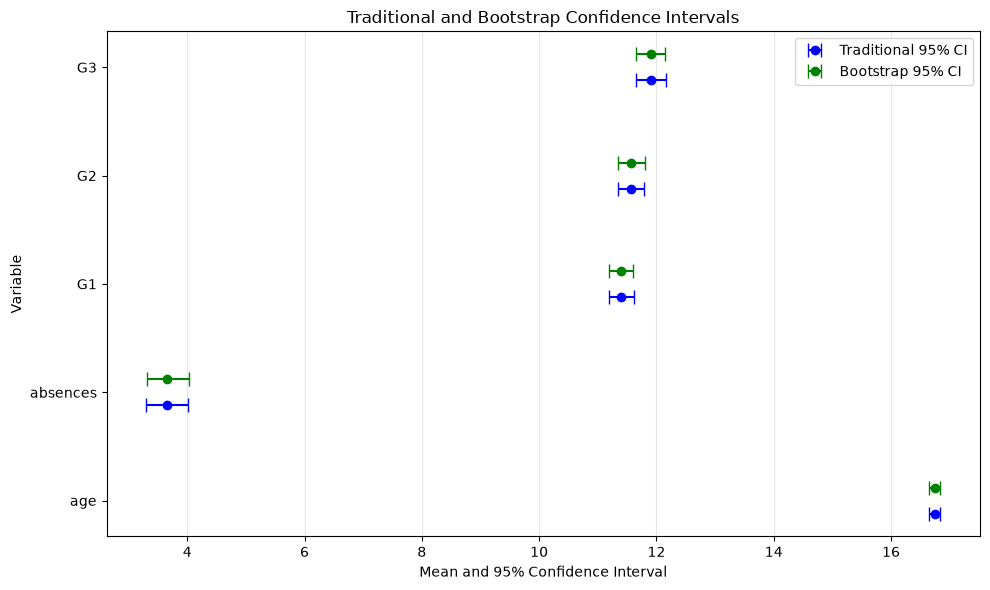

Saved to: /Users/hsumonsan/Statistics-superstars/reports/figures/confidence_intervals_comparison.png


In [4]:
positions = np.arange(len(comparison_df))
offset = 0.12

traditional_lower_error = (
    comparison_df["mean"]
    - comparison_df["ci_lower"]
)

traditional_upper_error = (
    comparison_df["ci_upper"]
    - comparison_df["mean"]
)

bootstrap_lower_error = (
    comparison_df["mean"]
    - comparison_df["bootstrap_lower"]
)

bootstrap_upper_error = (
    comparison_df["bootstrap_upper"]
    - comparison_df["mean"]
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    comparison_df["mean"],
    positions - offset,
    xerr=[
        traditional_lower_error,
        traditional_upper_error
    ],
    fmt="o",
    capsize=5,
    color="blue",
    label="Traditional 95% CI"
)

plt.errorbar(
    comparison_df["mean"],
    positions + offset,
    xerr=[
        bootstrap_lower_error,
        bootstrap_upper_error
    ],
    fmt="o",
    capsize=5,
    color="green",
    label="Bootstrap 95% CI"
)

plt.yticks(
    positions,
    comparison_df["column"]
)

plt.xlabel("Mean and 95% Confidence Interval")
plt.ylabel("Variable")
plt.title(
    "Traditional and Bootstrap Confidence Intervals"
)

plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

confidence_figure_file = (
    FIGURES_DIR
    / "confidence_intervals_comparison.png"
)

plt.savefig(
    confidence_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved to:", confidence_figure_file)